# Dokumen Exploratory Data Analysis (EDA) - AWAL

### Analisis Supply vs Demand Kompetensi Kerja

Dokumen ini berisi penjelasan terstruktur mengenai tahapan Eksplorasi Data (*Exploratory Data Analysis* - EDA) yang dijalankan pada proyek analisis keselarasan keahlian kerja. Analisis ini berfokus pada perbandingan antara **Supply** (Keahlian yang dimiliki oleh pelamar kerja) dan **Demand** (Standar kompetensi kerja industri).

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

sns.set_theme(style="ticks", palette="pastel")

In [ ]:
# 1. PERSIAPAN DATA
print("Memuat dataset untuk Fase Kolaborasi...")
df_resume = pd.read_csv('cleaned_training_data.csv')
df_skills = pd.read_csv('cleaned_skills_list.csv')
df_skkni = pd.read_csv('data_pekerjaan.csv')

def parse_skills(skill_data):
    if pd.isna(skill_data):
        return []
    try:
        # Membaca format list string (contoh: "['python', 'java']")
        return ast.literal_eval(skill_data)
    except:
        return [s.strip() for s in str(skill_data).replace('[', '').replace(']', '').replace("'", "").split(',')]

df_resume['skills_clean_list'] = df_resume['skills_clean'].apply(parse_skills)

Memuat dataset untuk Fase Kolaborasi...


### Penjelasan Data yang Digunakan:
1. cleaned_training_data.csv (df_resume): Data resume pelamar kerja (sumber: Kaggle) yang merepresentasikan Supply (ketersediaan tenaga kerja).

2. cleaned_skills_list.csv (df_skills): Daftar pustaka nama-nama keahlian (skills) yang sudah dibersihkan.

3. data_pekerjaan.csv (df_skkni): Dataset regulasi dokumen SKKNI (Standar Kompetensi Kerja Nasional Indonesia) yang merepresentasikan Demand (kebutuhan kompetensi riil industri di Indonesia).

### Penataan Struktur Data (Parsing) :
Karena kolom teks keahlian pada data resume sering kali tersimpan dalam bentuk string representasi list (contoh: "['python', 'java']"), diperlukan proses konversi menggunakan fungsi ast.literal_eval agar data kembali menjadi struktur objek list Python murni.

In [ ]:
# PROSES EDA: MENGHITUNG DISTRIBUSI (SUPPLY VS DEMAND)
print("Menghitung distribusi skill...")
# A. Supply: Menghitung Top 10 Skill paling banyak muncul di Resume
semua_skill_resume = [skill for sublist in df_resume['skills_clean_list'] for skill in sublist if skill]
frekuensi_skill = Counter(semua_skill_resume).most_common(10)
df_top_resume = pd.DataFrame(frekuensi_skill, columns=['Skill_Kaggle', 'Jumlah'])

# B. Demand: Menghitung Top 10 Unit Kompetensi yang paling sering dirujuk di SKKNI
# (Menggunakan 'Judul Unit' sebagai representasi skill dari SKKNI)
frekuensi_skkni = df_skkni['Judul Unit'].value_counts().head(10).reset_index()
frekuensi_skkni.columns = ['Unit_SKKNI', 'Jumlah']

Menghitung distribusi skill...


### Visualisasi Data dan Hasil Analisis
Untuk mempermudah interpretasi perbandingan, visualisasi disajikan dalam bentuk grafis diagram batang horizontal (Horizontal Bar Chart) berdampingan (1 row, 2 columns).

Membuat visualisasi EDA...


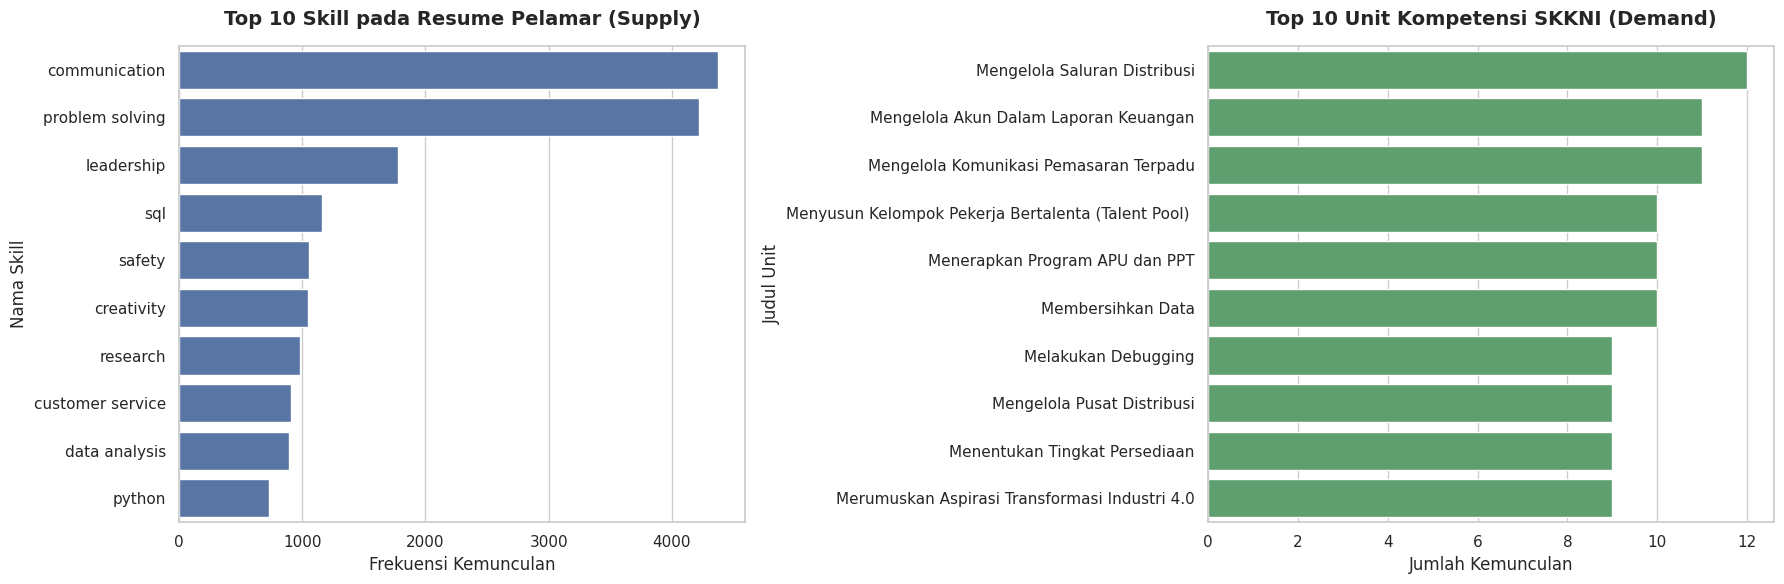

In [ ]:
# VISUALISASI EDA
print("Membuat visualisasi EDA...")
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top Supply (Resume Kaggle)
sns.barplot(data=df_top_resume, y='Skill_Kaggle', x='Jumlah', ax=axes[0], color="#4C72B0")
axes[0].set_title('Top 10 Skill pada Resume Pelamar (Supply)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Frekuensi Kemunculan', fontsize=12)
axes[0].set_ylabel('Nama Skill', fontsize=12)

# Top Demand (SKKNI)
sns.barplot(data=frekuensi_skkni, y='Unit_SKKNI', x='Jumlah', ax=axes[1], color="#55A868")
axes[1].set_title('Top 10 Unit Kompetensi SKKNI (Demand)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Jumlah Kemunculan', fontsize=12)
axes[1].set_ylabel('Judul Unit', fontsize=12)

plt.tight_layout()
plt.show()

### Penjelasan Hasil Visualisasi:
Grafik Kiri: Top 10 Skill pada Resume Pelamar (Supply)

- Tujuan: Menampilkan 10 jenis keahlian teknologi/industri global yang paling umum dicantumkan oleh para pelamar di dalam resume mereka.

- Hasil Teoretis: Grafik ini didominasi oleh kemampuan teknis populer berskala internasional (seperti bahasa pemrograman Python, SQL, Analisis Data, dll.) yang mencerminkan profil kompetensi kandidat siap kerja secara global.

### Grafik Kanan: Top 10 Unit Kompetensi SKKNI (Demand)

- Tujuan: Menampilkan 10 unit judul kompetensi standar nasional yang paling krusial dan paling sering digunakan di berbagai klasifikasi jabatan kerja regulasi Indonesia.

- Hasil Teoretis: Grafik ini didominasi oleh nomenklatur resmi bahasa regulasi kerja nasional (seperti pengoperasian komputer dasar, keselamatan kerja/K3, atau administrasi sistem).

In [ ]:
# PEMBUATAN KAMUS MAPPING (LOOKUP TABLE)
print("Menyusun kamus mapping SKKNI...")
skill_unik_kaggle = df_skills['Skill Name Clean'].dropna().unique()

df_mapping = pd.DataFrame({'Skill_Internasional_Kaggle': skill_unik_kaggle})

# Menambahkan kolom kosong untuk diisi acuan SKKNI
df_mapping['Kode_Unit_SKKNI'] = ""
df_mapping['Judul_Unit_SKKNI'] = ""
df_mapping['Kecocokan'] = "Belum Dipetakan"

# Menyimpan referensi SKKNI utuh agar tim AI Engineer mudah mencari referensinya
df_referensi_skkni = df_skkni[['Kode Unit', 'Judul Unit', 'Elemen Kompetensi', 'Jabatan']].drop_duplicates()

Menyusun kamus mapping SKKNI...


In [ ]:
# 5. EXPORT HASIL
df_mapping.to_csv('skill_mapping_dictionary.csv', index=False)
df_referensi_skkni.to_csv('skkni_reference_clean.csv', index=False)

print("\n=== SELESAI ===")
print("File 'skill_mapping_dictionary.csv' dan 'skkni_reference_clean.csv' berhasil dibuat.")


=== SELESAI ===
File 'skill_mapping_dictionary.csv' dan 'skkni_reference_clean.csv' berhasil dibuat.
